In [11]:
import sys, os
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
# os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
# import pickle as pk
import numpy as np
import torch
dev = torch.device("mps")
import torch.optim as optim
# from torch.distributions import MultivariateNormal
# from torch.distributions import Normal
# root_dir = '/mnt/home/spandey/ceph/AR_NPE/'
# os.chdir(root_dir)
# import colossus
import sys, os
# append the root_dir to the path
# sys.path.append(root_dir)
# from nf.combined_models_wmaskSumGauss import COMBINED_Model
# from nf.combined_models_classification import COMBINED_Model
# from nf.all_models import *
# from nf.utils_data_prep_cosmo import *
# from tqdm import tqdm
# import pyyaml
from colossus.cosmology import cosmology
params = {'flat': True, 'H0': 67.11, 'Om0': 0.3175, 'Ob0': 0.049, 'sigma8': 0.834, 'ns': 0.9624}
cosmo = cosmology.setCosmology('myCosmo', **params)
# get halo mass function:
from colossus.lss import mass_function
from tqdm import tqdm
    
import yaml
import pickle as pk
# autoreload modules
%load_ext autoreload
%autoreload 2

import matplotlib
%matplotlib inline
import matplotlib.pyplot as pl
import numpy as np
import sys,os
# import readgadget
# import MAS_library as MASL
import pickle as pk
# import readfof
import matplotlib

import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
# Palatino
pl.rc('font', family='DejaVu Sans')
%matplotlib inline



# %load_ext Cython


        
        
        



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
def PDM_to_vector(pdm):
    """
    Transforms a positive definite matrix of dimension :math:`d \\times d`
    into an unconstrained vector of dimension :math:`d(d+1)/2`.
    This does not use the Cholesky decomposition since we need guarantee of
    strictly positive definiteness.

    The absolute values of the elements with indexes of the returned vector
    that satisfy:

    .. code-block:: python

        np.tril_indices(d, 0)[0] == np.tril_indices(d, 0)[1]

    are the eigenvalues of the matrix. The sign of these elements define
    the orientation of the eigenvectors.

    Note that this is not strictly the inverse of
    :meth:`tensiometer.utilities.vector_to_PDM`
    since there are a number of discrete symmetries in the definition of the
    eigenvectors that we ignore since they are irrelevant for the sake of
    representing the matrix.

    :param pdm: the input positive definite matrix.
    :return: output vector representation.
    :reference: https://arxiv.org/abs/1906.00587
    """
    # get dimension:
    d = pdm.shape[0]
    # get the eigenvalues of the matrix:
    Lambda, Phi = np.linalg.eigh(pdm)
    # get triangular decomposition:
    (P, L, U) = scipy.linalg.lu(Phi.T, permute_l=False)
    # WR decomposition:
    Q, R = np.linalg.qr(L)
    L = np.dot(np.dot(R, U), L)
    # pivot the eigenvalues:
    Lambda2 = np.dot(np.dot(P.T, np.diag(Lambda)), P)
    # prepare output:
    mat = L
    mat[np.diag_indices(d)] = np.sign(mat[np.diag_indices(d)])*np.diag(Lambda2)
    #
    return mat[np.tril_indices(d, 0)]


def vector_to_PDM(vec):
    """
    Transforms an unconstrained vector of dimension :math:`d(d+1)/2`
    into a positive definite matrix of dimension :math:`d \\times d`.
    In the input vector the eigenvalues are in the positions where

    The absolute values of the elements with indexes of the input vector
    that satisfy:

    .. code-block:: python

        np.tril_indices(d, 0)[0] == np.tril_indices(d, 0)[1]

    are the eigenvalues of the matrix. The sign of these elements define
    the orientation of the eigenvectors.

    The purpose of this function is to allow optimization over the space
    of positive definite matrices that is either unconstrained or
    has constraints on the condition number of the matrix.

    :param pdm: the input vector.
    :return: output positive definite matrix.
    :reference: https://arxiv.org/abs/1906.00587
    """
    d = int(np.sqrt(1 + 8*len(vec)) - 1)//2
    L = np.zeros((d, d))
    # get the diagonal with eigenvalues:
    L[np.tril_indices(d, 0)] = vec
    Lambda2 = np.diag(np.abs(L[np.diag_indices(d)]))
    L[np.diag_indices(d)] = np.sign(L[np.diag_indices(d)]) * np.ones(d)
    # qr decompose L:
    Q, R = np.linalg.qr(L)
    Phi2 = np.dot(L, np.linalg.inv(R))
    # rebuild matrix
    return np.dot(np.dot(Phi2.T, Lambda2), Phi2)
    

In [6]:
# from sklearn.datasets import make_moons
# x_moon, y_moon = make_moons(n_samples=500000, noise=0.01, random_state=None)

# pl.figure()
# pl.scatter(x_moon[:,0], x_moon[:,1], s=0.1)

import pickle as pk
from getdist import plots, MCSamples
from getdist.gaussian_mixtures import MixtureND
num_gaussians = 5
num_params = 5
#num_samples = 10000
# num_samples = int(100000 * (num_params / 10)**2)
num_samples_final = 1e5

mean_range = [-2, 2]
means = np.random.uniform(mean_range[0], mean_range[1], num_gaussians*num_params).reshape(num_gaussians, num_params)
weights = np.random.rand(num_gaussians)
covs = [vector_to_PDM(np.random.rand(int(num_params*(num_params+1)/2))) for _ in range(num_gaussians)]

distribution = MixtureND(means, covs, weights, label='Mixture')      
chain = distribution.MCSamples(num_samples_final, logLikes=True) 



Removed no burn in


In [8]:
x_moon = chain.samples


In [9]:
# scale each dimension to [0,1]:
data_scaled = np.zeros_like(x_moon)
ndim_data = x_moon.shape[1]
min_data_all = np.zeros(ndim_data)
max_data_all = np.zeros(ndim_data)
fac_scale = 1.1
for i in range(ndim_data):
    data_scaled[:,i] = (x_moon[:,i]-fac_scale*np.min(x_moon[:,i]))/(fac_scale*(np.max(x_moon[:,i])-np.min(x_moon[:,i])))
    min_data_all[i] = fac_scale*np.min(x_moon[:,i])
    max_data_all[i] = fac_scale*np.max(x_moon[:,i])


(0.0, 1.0)

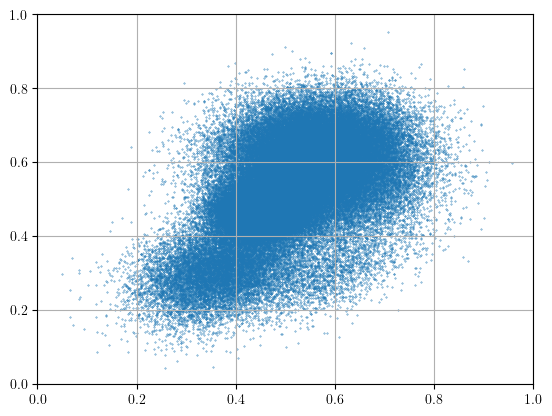

In [13]:
pl.figure()
pl.scatter(data_scaled[:,0], data_scaled[:,1], s=0.1)
pl.grid()
pl.xlim(0,1)
pl.ylim(0,1)


In [14]:
nvocab = 1024
bins_digitize = np.linspace(-1e-3, 1, nvocab)
data_digitized = np.digitize(data_scaled, bins_digitize)




In [15]:
# prepend 0 to first axis for all data:
start_token = 0
data_digitized = np.concatenate([start_token + np.zeros((data_digitized.shape[0], 1)), data_digitized], axis=1)




In [16]:
n = int(0.8*len(data_digitized)) # first 90% will be train, rest val
train_data = data_digitized[:n]
val_data = data_digitized[n:]



In [17]:
train_data.shape

(80000, 6)

In [18]:
device = 'cuda'

x = torch.tensor(train_data[:, :-1]).long()
y = torch.tensor(train_data[:, 1:]).long()
x, y = torch.tensor(x).to(device), torch.tensor(y).to(device)
x_train = x.long()
y_train = y.long()

x = torch.tensor(val_data[:, :-1]).long()
y = torch.tensor(val_data[:, 1:]).long()

x, y = torch.tensor(x).to(device), torch.tensor(y).to(device)
x_val = x.long()
y_val = y.long()



/tmp/ipykernel_1676661/3545606205.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x, y = torch.tensor(x).to(device), torch.tensor(y).to(device)
/tmp/ipykernel_1676661/3545606205.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x, y = torch.tensor(x).to(device), torch.tensor(y).to(device)


In [19]:
# x_train.shape, y_train.shape

In [21]:
import torch
import torch.nn as nn
from torch.nn import functional as F

# hyperparameters
# batch_size = 16 # how many independent sequences will we process in parallel?
# block_size = 32 # what is the maximum context length for predictions?
max_iters = 5000
eval_interval = 10
learning_rate = 1e-3
# device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 200
n_embd = 24
n_head = 2
n_layer = 2
dropout = 0.2
# ------------
vocab_size = nvocab + 1
block_size = ndim_data
batch_size = 65536*1



In [22]:
def get_batch(split, batch_size=None):
    if split == 'train':
        x = x_train
        y = y_train
        # mask = mask_train
    elif split == 'val':
        x = x_val
        y = y_val
        # mask = mask_val
    if batch_size is not None:
        x = x[:batch_size]
        y = y[:batch_size]
        # mask = mask[:batch_size]
    return x, y
    # return x, y

class mySequential(nn.Sequential):
    def forward(self, *inputs):
        for module in self._modules.values():
            if type(inputs) == tuple:
                inputs = module(*inputs)
            else:
                inputs = module(inputs)
        return inputs

class Head(nn.Module):
    """ one head of self-attention """

    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        x = x
        B,T,C = x.shape
        k = self.key(x)   # (B,T,C)
        q = self.query(x) # (B,T,C)
        # compute attention scores ("affinities")
        wei = q @ k.transpose(-2,-1) * C**-0.5 # (B, T, C) @ (B, C, T) -> (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # (B, T, T)
        if mask is not None:
            wei += mask
        wei = F.softmax(wei, dim=-1) # (B, T, T)
        wei = self.dropout(wei)
        # perform the weighted aggregation of the values
        v = self.value(x) # (B,T,C)
        out = wei @ v # (B, T, T) @ (B, T, C) -> (B, T, C)
        return out

class MultiHeadAttention(nn.Module):
    """ multiple heads of self-attention in parallel """

    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        out = torch.cat([h(x, mask) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

class FeedFoward(nn.Module):
    """ a simple linear layer followed by a non-linearity """

    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    """ Transformer block: communication followed by computation """

    def __init__(self, n_embd, n_head):
        # n_embd: embedding dimension, n_head: the number of heads we'd like
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedFoward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x, mask):
        x = x + self.sa(self.ln1(x), mask)
        x = x + self.ffwd(self.ln2(x))
        return x
    
# super simple bigram model
class HaloDecoderModel(nn.Module):

    def __init__(self):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        # self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        self.blocks = nn.ModuleList([Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        # self.blocks = mySequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd) # final layer norm
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None, mask=None):
        B, T = idx.shape

        # idx and targets are both (B,T) tensor of integers
        tok_emb = self.token_embedding_table(idx) # (B,T,C)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device)) # (T,C)
        x = tok_emb + pos_emb # (B,T,C)
        # x = self.blocks(x) # (B,T,C)
        # x = self.blocks((x,mask)) # (B,T,C)        
        for block in self.blocks:
            x = block(x, mask)
        
        x = self.ln_f(x) # (B,T,C)
        logits = self.lm_head(x) # (B,T,vocab_size)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)

            loss = F.cross_entropy(logits, targets, ignore_index=1)

        return logits, loss

    def generate(self, idx_inp, max_new_tokens, nvox_samp=32):
        # idx is (B, T) array of indices in the current context
        idx_all = []
        for jv in range(nvox_samp):
            idx = idx_inp
            for _ in range(max_new_tokens):
                # crop idx to the last block_size tokens
                idx_cond = idx[:, -block_size:]
                # get the predictions
                logits, loss = self(idx_cond)
                # focus only on the last time step
                logits = logits[:, -1, :] # becomes (B, C)
                # apply softmax to get probabilities
                probs = F.softmax(logits, dim=-1) # (B, C)
                # sample from the distribution
                idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
                # append sampled index to the running sequence
                # if idx_next == end_token:
                    # break
                idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
            idx_all.append(idx)
        return idx_all





In [23]:
model = HaloDecoderModel()
m = model.to(device)
# print the number of parameters in the model
print(sum(p.numel() for p in m.parameters())/1e6, 'M parameters')

# create a PyTorch optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)



0.064697 M parameters


In [24]:
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split, batch_size)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out




In [57]:
val_loss_min = 1e20
# saved = {}
for iter in range(max_iters):

    # every once in a while evaluate the loss on train and val sets
    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss()
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

        # save the model if it's better than the previous best:
        if losses['val'] < val_loss_min:
            val_loss_min = losses['val']
            torch.save(model.state_dict(), 'model.pt')
            print(f"New best model saved with loss {val_loss_min:.4f}")

    # sample a batch of data
    xb, yb = get_batch('train', batch_size)

    # evaluate the loss
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()




step 0: train loss 5.9687, val loss 5.9956
New best model saved with loss 5.9956
step 10: train loss 5.9675, val loss 5.9949
New best model saved with loss 5.9949
step 20: train loss 5.9664, val loss 5.9943
New best model saved with loss 5.9943
step 30: train loss 5.9652, val loss 5.9935
New best model saved with loss 5.9935
step 40: train loss 5.9642, val loss 5.9931
New best model saved with loss 5.9931
step 50: train loss 5.9630, val loss 5.9923
New best model saved with loss 5.9923
step 60: train loss 5.9618, val loss 5.9917
New best model saved with loss 5.9917
step 70: train loss 5.9607, val loss 5.9911
New best model saved with loss 5.9911
step 80: train loss 5.9595, val loss 5.9905
New best model saved with loss 5.9905
step 90: train loss 5.9584, val loss 5.9900
New best model saved with loss 5.9900
step 100: train loss 5.9573, val loss 5.9894
New best model saved with loss 5.9894
step 110: train loss 5.9561, val loss 5.9888
New best model saved with loss 5.9888
step 120: train

KeyboardInterrupt: 

In [58]:
nvox_samp = 16384
idx_inp = torch.zeros((nvox_samp, 1), dtype=torch.long, device=device)

max_new_tokens = ndim_data
# idx_all = []
# for jv in range(nvox_samp):
idx = idx_inp
for _ in range(max_new_tokens):
    # crop idx to the last block_size tokens
    idx_cond = idx[:, -block_size:]
    # get the predictions
    logits, loss = m(idx_cond)
    # focus only on the last time step
    logits = logits[:, -1, :] # becomes (B, C)
    # apply softmax to get probabilities
    probs = F.softmax(logits, dim=-1) # (B, C)
    # sample from the distribution
    idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
    # append sampled index to the running sequence
    # if idx_next == end_token:
        # break
    idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
# idx_all.append(idx.detach().cpu().numpy())
    

In [59]:
idx.shape


torch.Size([16384, 6])

In [60]:
# np.array(idx_all).shape
# idx_out = np.array(idx_all)[:,0,1:]
idx_out = (idx.detach().cpu().numpy())[:,1:]
idx_out.shape


(16384, 5)

In [61]:
# np.amax(idx_out)
idx_out[0,:]


array([463, 452, 515, 537, 623])

In [62]:
data_set_out_detokenized = np.zeros(idx_out.shape)
for i in range(ndim_data):
    try:
        data_set_out_detokenized[:,i] = bins_digitize[idx_out[:,i]]
    except:
        pass



In [63]:
y_detokenized = np.zeros(y_val.shape)
for i in range(ndim_data):
    y_detokenized[:,i] = bins_digitize[y_val[:,i].detach().cpu().numpy()]



In [64]:
chain_samps = MCSamples(samples=data_set_out_detokenized)
chain_true = MCSamples(samples=y_detokenized)


Removed no burn in
Removed no burn in


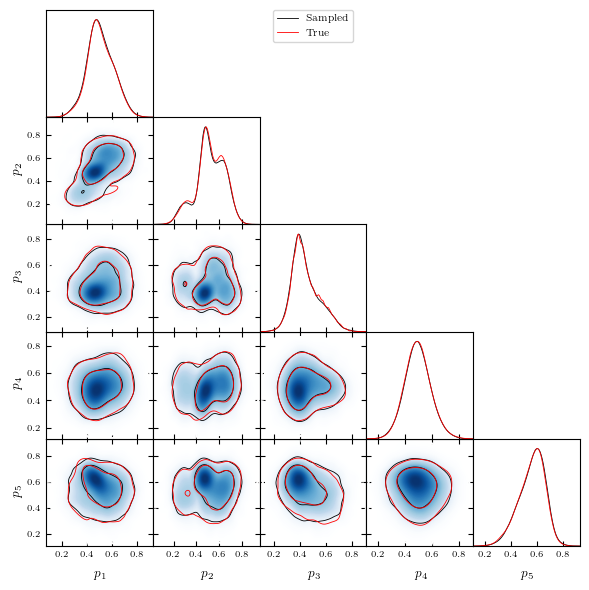

In [71]:
from getdist import plots, MCSamples
g = plots.get_subplot_plotter(width_inch=6)
# g.triangle_plot([chain_samps, chain_true], params=chain_true.getParamNames().list()[:2], filled=True)
g.triangle_plot([chain_samps, chain_true], filled=False, shaded=True, legend_labels=['Sampled','True'])
g.export('/mnt/home/spandey/ceph/CHARFORMER/notebooks/transformer_decoder.pdf')




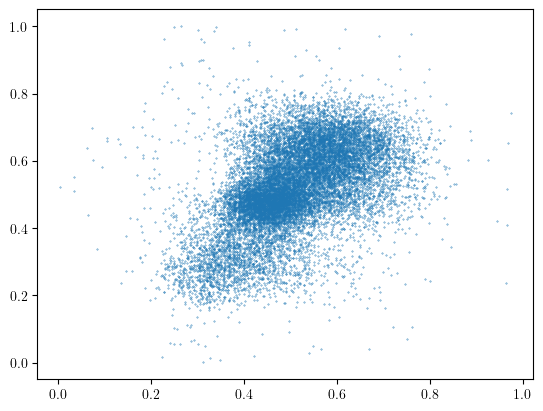

In [56]:
pl.figure()
pl.scatter(data_set_out_detokenized[:,0], data_set_out_detokenized[:,1], s=0.1)


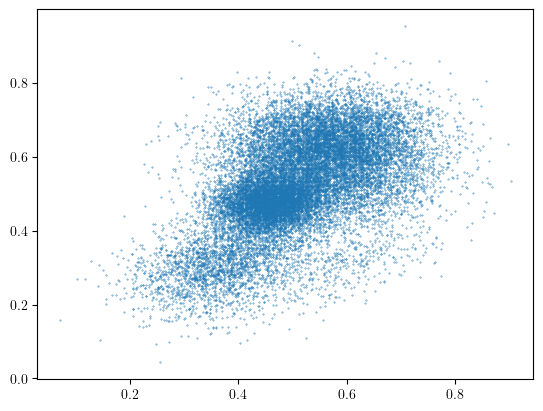

In [32]:
pl.figure()
pl.scatter(y_detokenized[:,0], y_detokenized[:,1], s=0.1)


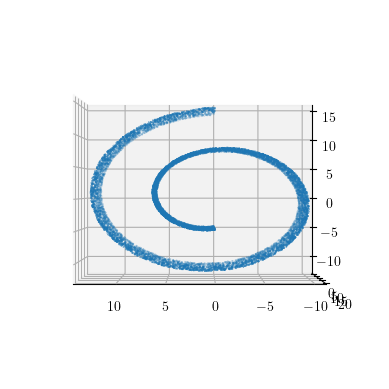

In [5]:
from sklearn.datasets import make_swiss_roll
X, t = make_swiss_roll(n_samples=10000, noise=0.01, random_state=0)

# pl.figure()
# pl.scatter(X[:,0], X[:,1], c=t, s=0.1)
fig = pl.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(X[:,0], X[:,1], X[:,2], s=0.1)
ax.view_init(0,90,0)
